# 03 - Linear Regression Model

Fit a linear regression model to predict Sales from advertising spend, and check residuals for violations of model assumptions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("../data/advertising_clean.csv", index_col=0)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 160 | Test size: 40


## Fit the model

In [2]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.4f}")

Intercept: 2.979067338122629
TV: 0.0447
Radio: 0.1892
Newspaper: 0.0028


**Interpretation:** the coefficient for each channel is the expected increase in Sales (in thousands of units) for a one-unit increase in that channel's spend (in thousands of dollars), holding the others fixed.

## Check residuals

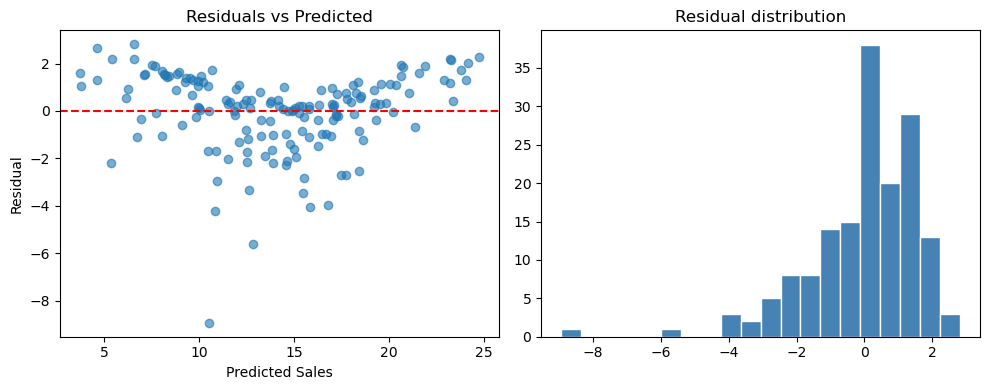

In [3]:
y_pred_train = model.predict(X_train)
residuals = y_train - y_pred_train

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(y_pred_train, residuals, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted Sales")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title("Residual distribution")
plt.tight_layout()
plt.savefig("../outputs/03_residuals.png", dpi=100)
plt.show()

**Observation:** residuals are roughly centered around zero with no obvious funnel shape, suggesting the linear model is a reasonable fit. A slight curve at low predicted values hints there may be a mild non-linear (interaction) effect between TV and Radio — worth noting as a limitation rather than fixing here, since the goal of this project is a simple linear baseline.

## Save test set predictions for the evaluation notebook

In [4]:
np.save("../outputs/y_test.npy", y_test.values)
np.save("../outputs/y_pred_test.npy", model.predict(X_test))
import joblib
joblib.dump(model, "../outputs/linear_model.pkl")
print("Model and predictions saved.")

Model and predictions saved.
